In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#df = pd.read_csv("data_fileA_enhanced.csv")
df = pd.read_csv("data_fileA.csv")

In [3]:
df.columns

Index(['id', 'age', 'status', 'gender', 'diet', 'drinks', 'height', 'income',
       'last_online', 'location', 'offspring', 'sign', 'smokes', 'speaks',
       'age_group', 'messages_sent', 'profile_completion', 'account_age',
       'preferred_age_range', 'subscription_type',
       'self_rated_attractiveness'],
      dtype='object')

In [4]:
df.head(2)

,id,age,status,gender,diet,drinks,height,income,last_online,location,...,sign,smokes,speaks,age_group,messages_sent,profile_completion,account_age,preferred_age_range,subscription_type,self_rated_attractiveness
0,618751,22,single,m,strictly anything,socially,75.0,-1,28/06/2012,"south san francisco, california",...,gemini,sometimes,english,18-24,102,59,3,18-27,Free,9
1,510466,35,single,m,mostly other,often,70.0,80000,29/06/2012,"oakland, california",...,cancer,no,"english (fluently), spanish (poorly), french (...",35-44,435,77,1,30-40,Free,5


# Q1

## <div dir='rtl'> <span style="color: #5A5A5A"> מצאו את המשכורת (income) החציונית של הגברים השייכים לשני המזלות (sign) הפופולאריים ביותר, ושדיווחו על משכורת.
<div dir='rtl'> 
הבהרות:
"דיווחו על משכורת" - יש אנשים שלא דיווחו על המשכורת שלהם. אין לקחת אותם בחשבון בעת החישוב. 
<div dir='rtl'> 
 דוגמה למי שמתקשה בהבנת השאלה: אם שני המזלות הנפוצים ביותר בדאטה הם מזל סרטן ומזל מאזניים, אז יש למצוא את המשכורת החציונית של הגברים השייכים למזלות סרטן ומאזניים. סוג המזל נמצא בעמודה sign.
<div dir='rtl'>     
בפלט יש להציג ערך מספרי אחד בלבד. תשובות שיציגו טבלה כלשהי יפסלו. 
</span>

In [5]:
sign1 = df["sign"].value_counts().index[0]
sign2 = df["sign"].value_counts().index[1]
median_income = df[((df.sign == sign1) | (df.sign == sign2)) & (df.gender == "m") & (df.income > 0)]["income"].median()
median_income

50000.0

# Q2

## <div dir='rtl'> <span style="color: #5A5A5A">   מצאו את אחוז האנשים בגילאי 20-30 ששלחו מעל 200 הודעות (messages_sent). <div dir='rtl'> <span style="color: #5A5A5A">  
<div dir='rtl'> הבהרות:
אנשים מעל גיל 20 ומתחת לגיל 30. 

In [6]:
x = df[(df['age'] > 20 ) & (df['age'] <30) & (df['messages_sent'] > 200)].shape[0]
x

16091

In [7]:
y = df.shape[0]
y

59946

In [8]:
percentage = x/y * 100
percentage

26.84249157575151

In [9]:
# Calculate average message rate (messages per year)
df['average_message_rate'] = df['messages_sent'] / df['account_age']

# Compute median average message rate
median_rate = df['average_message_rate'].median()

# Identify users above the median rate
best_users = df[df['average_message_rate'] > median_rate]
amount_best_users = len(best_users)
amount_best_users


29954

In [10]:
x = 2500
x

2500

# Q3


<div dir="rtl" style="text-align: right;">
מצאו את שלושת ההעדפות התזונתיות (**diet**) מהן נשלחו הכי הרבה הודעות (**messages_sent**).  
הציגו איור המראה את כמות ההודעות שנשלחו עבור כל אחת מהעדפות אלו, תוך הבחנה בין סוגי המנויים (**subscription_type**) של המשתמשים.
</div>

In [11]:
top_p = df.groupby(["diet"])[['messages_sent']].count().reset_index().sort_values(by="messages_sent", ascending=False).head(3)
top_p

,diet,messages_sent
3,mostly anything,16585
0,anything,6183
10,strictly anything,5113


In [12]:
p1, p2, p3 = top_p.iloc[0, 0], top_p.iloc[1, 0], top_p.iloc[2, 0]
print(p1)
print(p2)
print(p3)

mostly anything
anything
strictly anything


### count

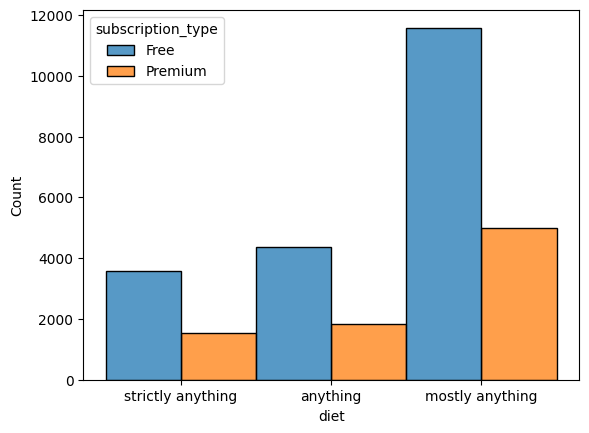

In [13]:
df2 = df[(df.diet == p1) | (df.diet == p2) | (df.diet == p3)]
sns.histplot(data=df2 ,x='diet', stat='count', hue='subscription_type', multiple = 'dodge')
plt.show()

### a nicer count (can also do sum)

In [14]:
filtered_df = df[df["diet"].isin([p1, p2, p3])]


<AxesSubplot: xlabel='diet', ylabel='messages_sent'>

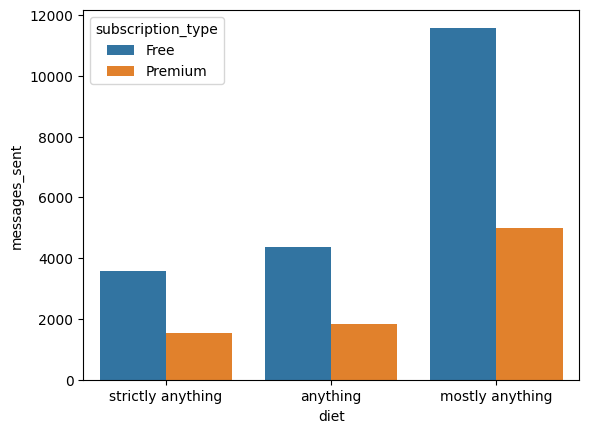

In [15]:
#sns.barplot(filtered_df , x ='diet',y = 'messages_sent', hue = 'subscription_type',estimator = sum)
sns.barplot(filtered_df , x ='diet',y = 'messages_sent', hue = 'subscription_type',estimator=lambda x: len(x))


### average 

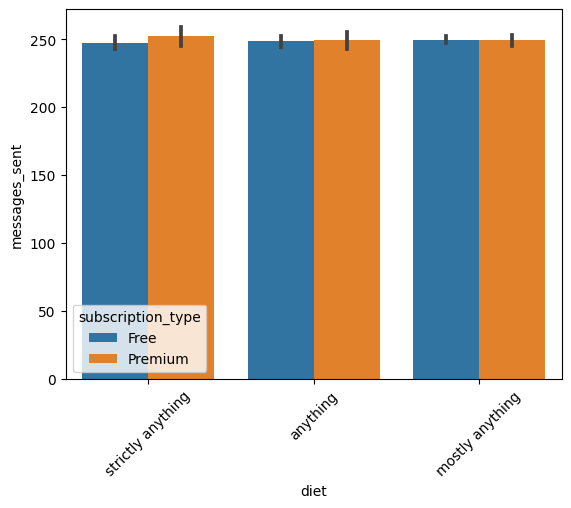

In [16]:

sns.barplot(data=filtered_df, x="diet", y="messages_sent", hue="subscription_type")
plt.xticks(rotation=45)
plt.show()

# Q4

<div dir='rtl'>
בעמודה (speaks) מופיעה רשימת השפות שכל משתמש מדבר, כאשר השפות מופרדות בפסיקים (`,`).  
<div dir='rtl'>
פצלו את העמודה כך שכל שפה תקבל עמודה משלה, ולאחר מכן המיסו (melt) את הנתונים כך שכל שפה תופיע בשורה נפרדת.  
מצאו את חמש השפות הנפוצות ביותר והציגו את שכיחותן באמצעות תרשים
countplot.



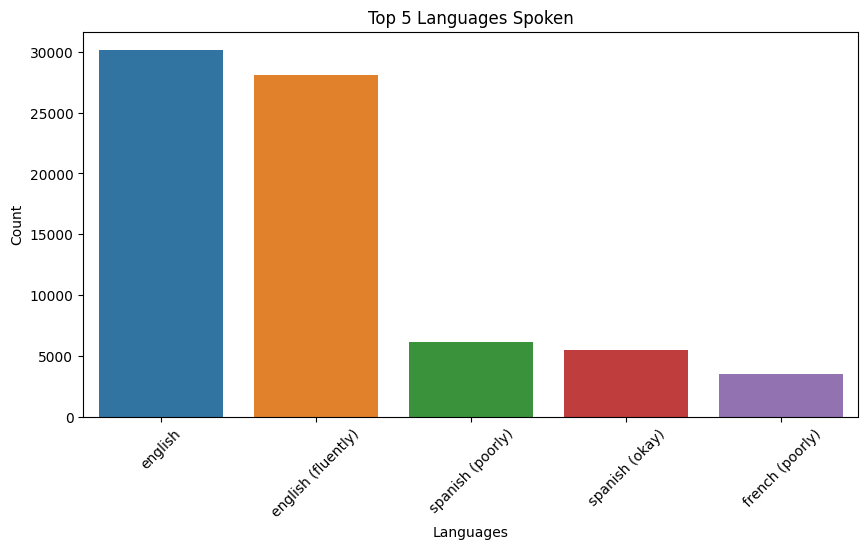

In [17]:
max_comma = int(df.speaks.str.count(',').max())  # Ensure it's an integer
list_s = df["speaks"].str.split(",", n=max_comma, expand=True)

for i in range(max_comma + 1):
    df[f"lang{i+1}"] = list_s[i]

ids = ['id']
values = ['lang1','lang2', 'lang3', 'lang4']
melted_df = pd.melt(df, id_vars= ids, value_vars= values)
melted_df = melted_df.rename(columns={'variable':'lang','value':'language'})

top_languages = melted_df["language"].value_counts().head(5).index

plt.figure(figsize=(10, 5))
sns.countplot(data=melted_df[melted_df["language"].isin(top_languages)], x="language", order=top_languages)
plt.xticks(rotation=45)
plt.xlabel("Languages")
plt.ylabel("Count")
plt.title("Top 5 Languages Spoken")
plt.show()



# Q5

<div dir='rtl'>
השתמשו ב FacetGrid  כדי להציג כמה איורים. 
<div dir='rtl'>
כל איור יציג הרגלי אכילה (diet) אחרים. בכל איור הציגו את התפלגות ה self rated atractiveness  באחוזים. 
<div dir='rtl'>
על כל איור להיות בצבע אחר. 
<div dir='rtl'>
הערה: אם אינכם מציליחים לבצע FacetGrid, פתרו את השאלה באופן אחר, כדי שלא ירדו לכם כל הנקודות. 


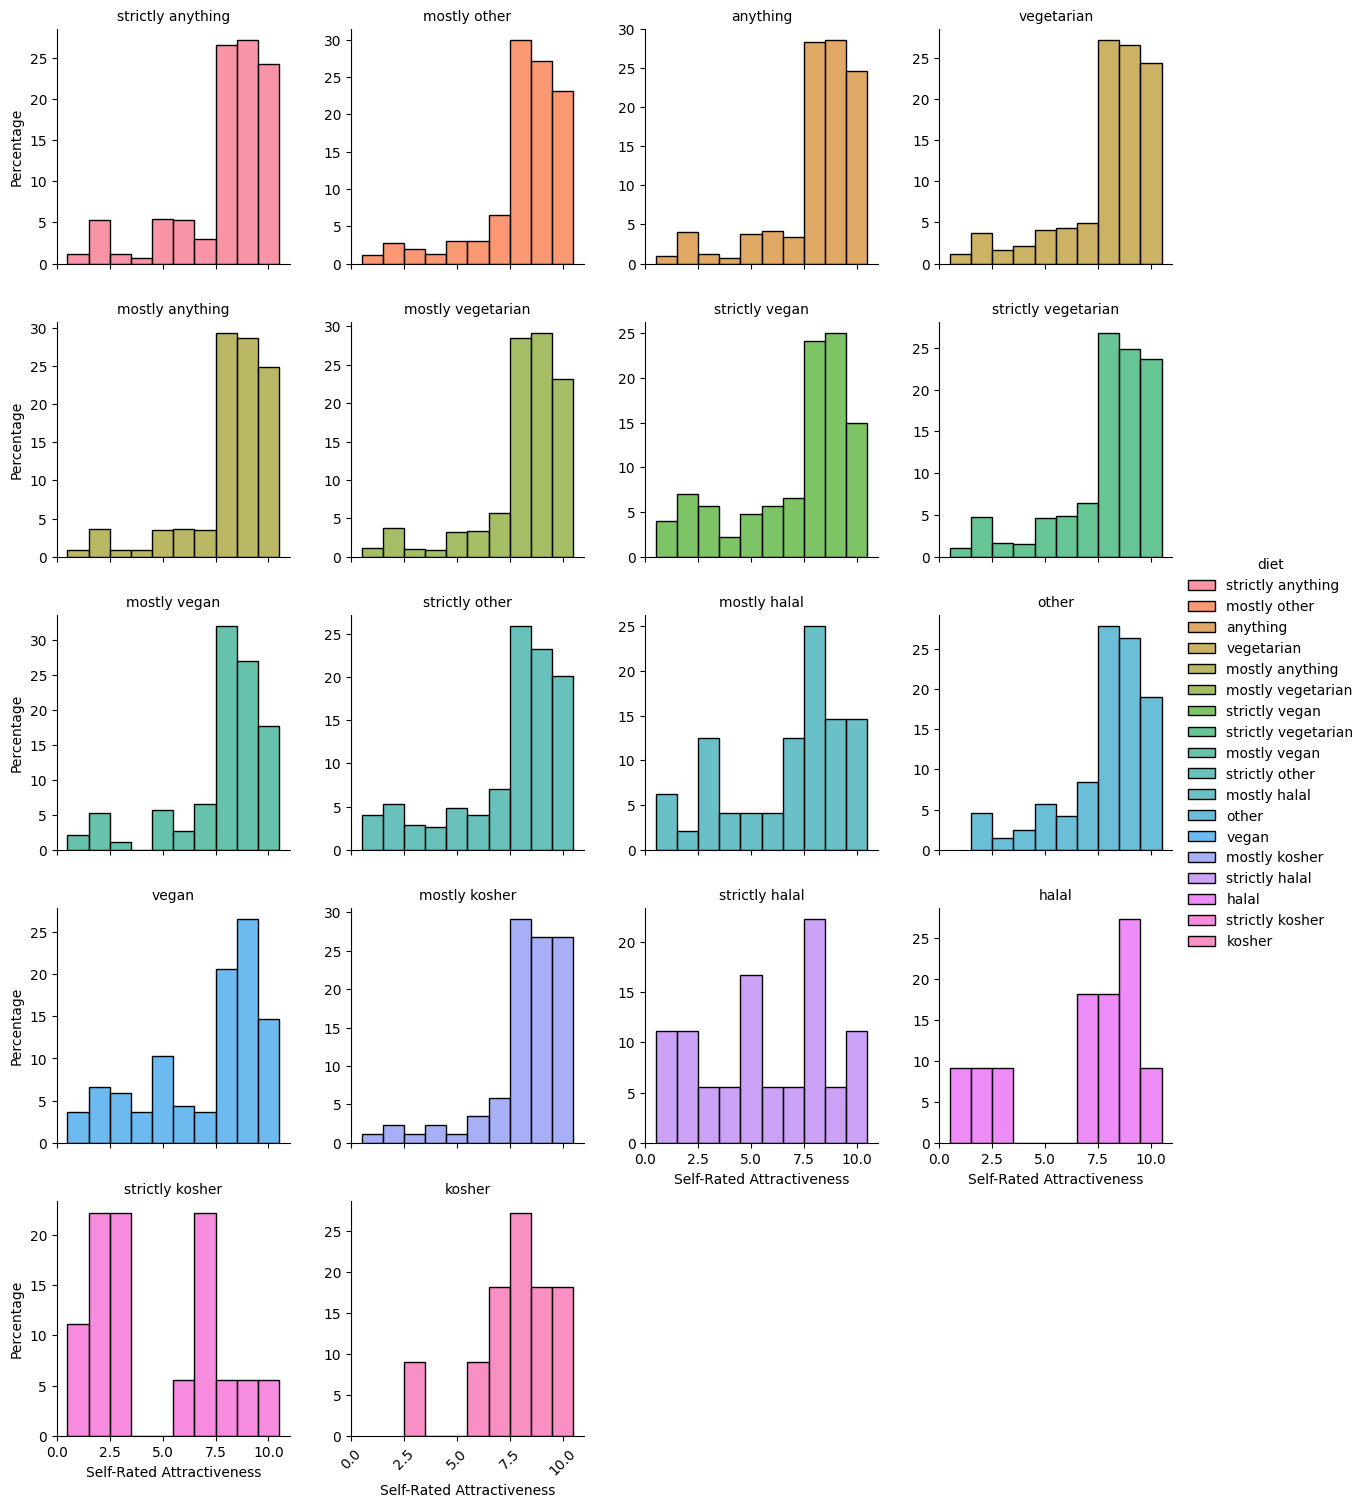

In [18]:
g = sns.FacetGrid(df, col="diet", col_wrap=4, sharex=True, sharey=False, hue="diet")

g.map_dataframe(sns.histplot, x="self_rated_attractiveness", stat="percent", discrete=True)

g.set_axis_labels("Self-Rated Attractiveness", "Percentage")
g.set_titles(col_template="{col_name}")
g.add_legend()
plt.xticks(rotation=45)
plt.show()



# Q6


<div dir='rtl'>
הציגו באיור את חציון הפרופילים שהושלמו(profile_completion) 
<div dir='rtl'>
עבור כל סוג מנוי (subscription_type) 
<div dir='rtl'>
בכל אחד מחודשי השנה (מתוך last_online)
<div dir='rtl'>
הבהרות: כן, יש לטפל תחילה בעמודה last_online כדי שתתאים. 
<div dir='rtl'>
ניתן להוסיף עמודות חדשות.
<div dir='rtl'>
אין צורך לטפל בעמודת profile_competion


C:\Users\lihin\AppData\Local\Temp\ipykernel_13540\3569780409.py:1: UserWarning: Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.
  df['last_online_date'] = pd.to_datetime(df['last_online'])


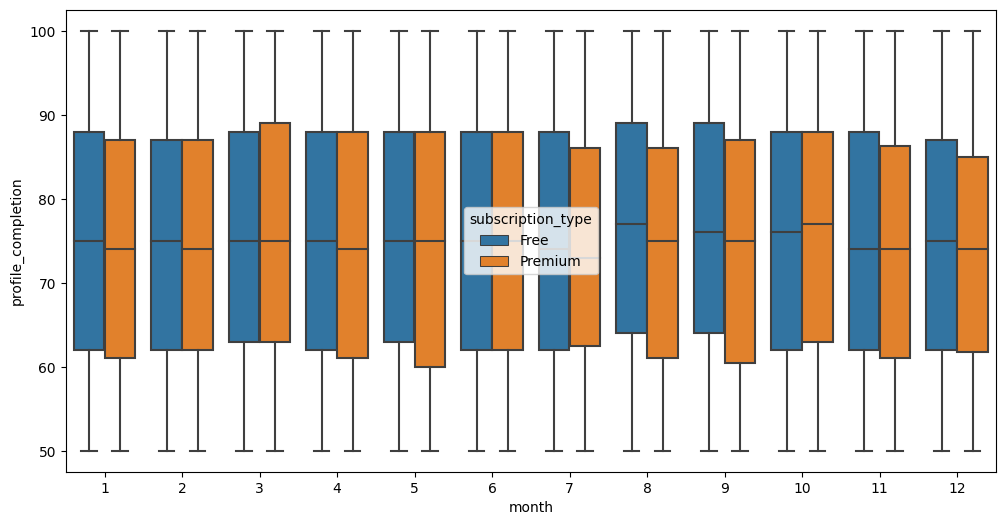

In [19]:

df['last_online_date'] = pd.to_datetime(df['last_online'])
df["month"] = df["last_online_date"].dt.month  # Extract month



plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="month", y="profile_completion", hue="subscription_type")


plt.show()




# Q7

<div dir='rtl'> צרו מפת חום (heatmap) המציגה את הקורלציות בין

['subscription_type',  'drinks', 'messages_sent' ,'self_rated_attractiveness']

<div dir='rtl'>
מצאו את הקשר החזק ביותר והציגו אותו באמצעות איור. 


In [20]:
categorical_features = ['subscription_type',  'drinks']
numeric_features = ['messages_sent' ,"self_rated_attractiveness"]
all_features = numeric_features + categorical_features

df_dummies = pd.get_dummies(df[all_features])
df_dummies.columns

Index(['messages_sent', 'self_rated_attractiveness', 'subscription_type_Free',
       'subscription_type_Premium', 'drinks_desperately', 'drinks_not at all',
       'drinks_often', 'drinks_rarely', 'drinks_socially',
       'drinks_very often'],
      dtype='object')

In [21]:
# Compute correlation matrix
correlation_matrix = df_dummies.corr()
correlation_matrix = df_dummies.corr(method= "spearman").round(2)

<AxesSubplot: xlabel='drinks', ylabel='self_rated_attractiveness'>

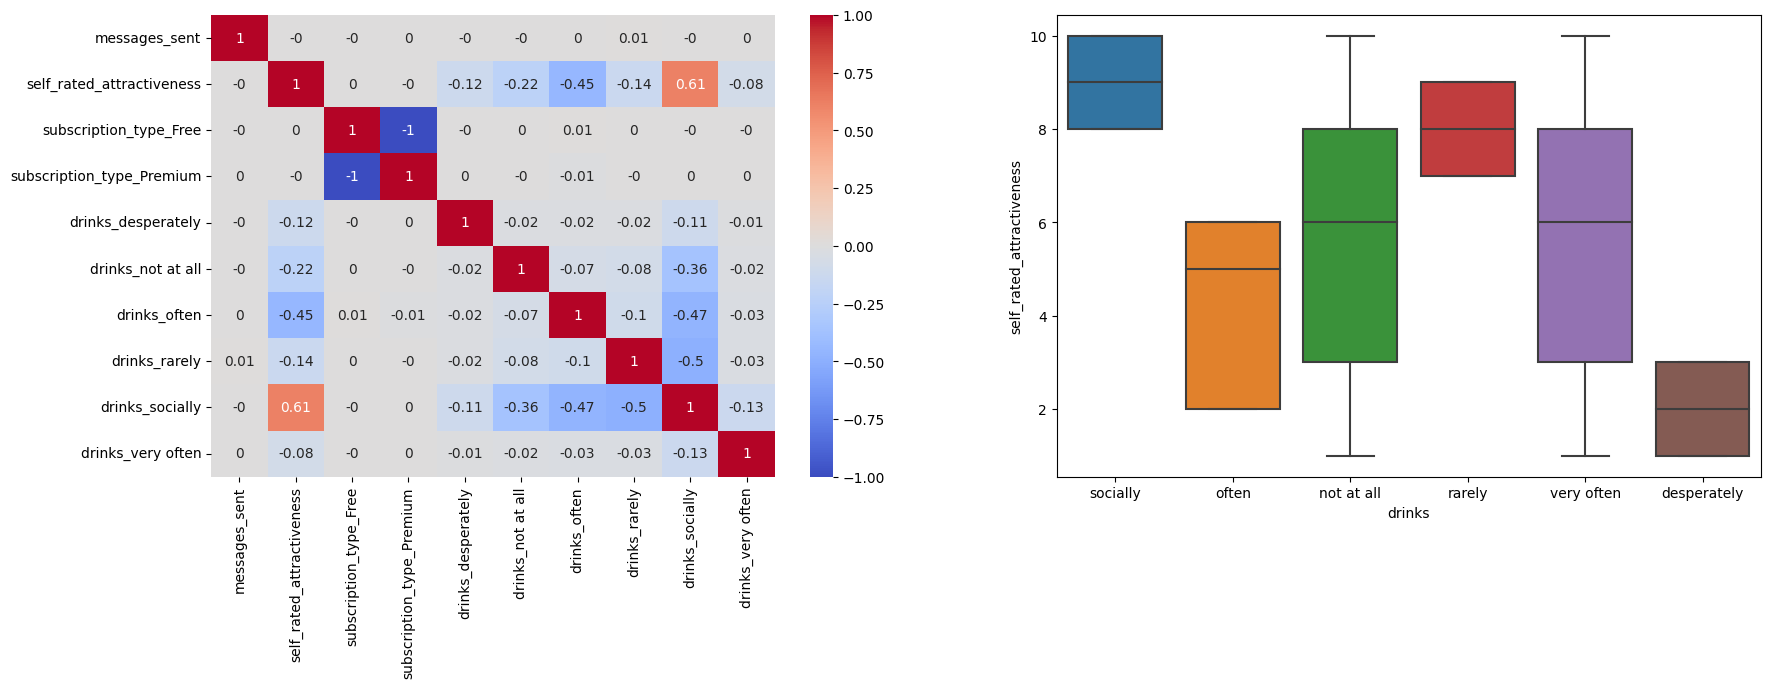

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', ax=axes[0])
sns.boxplot(df,y = "self_rated_attractiveness", x = "drinks", ax=axes[1])

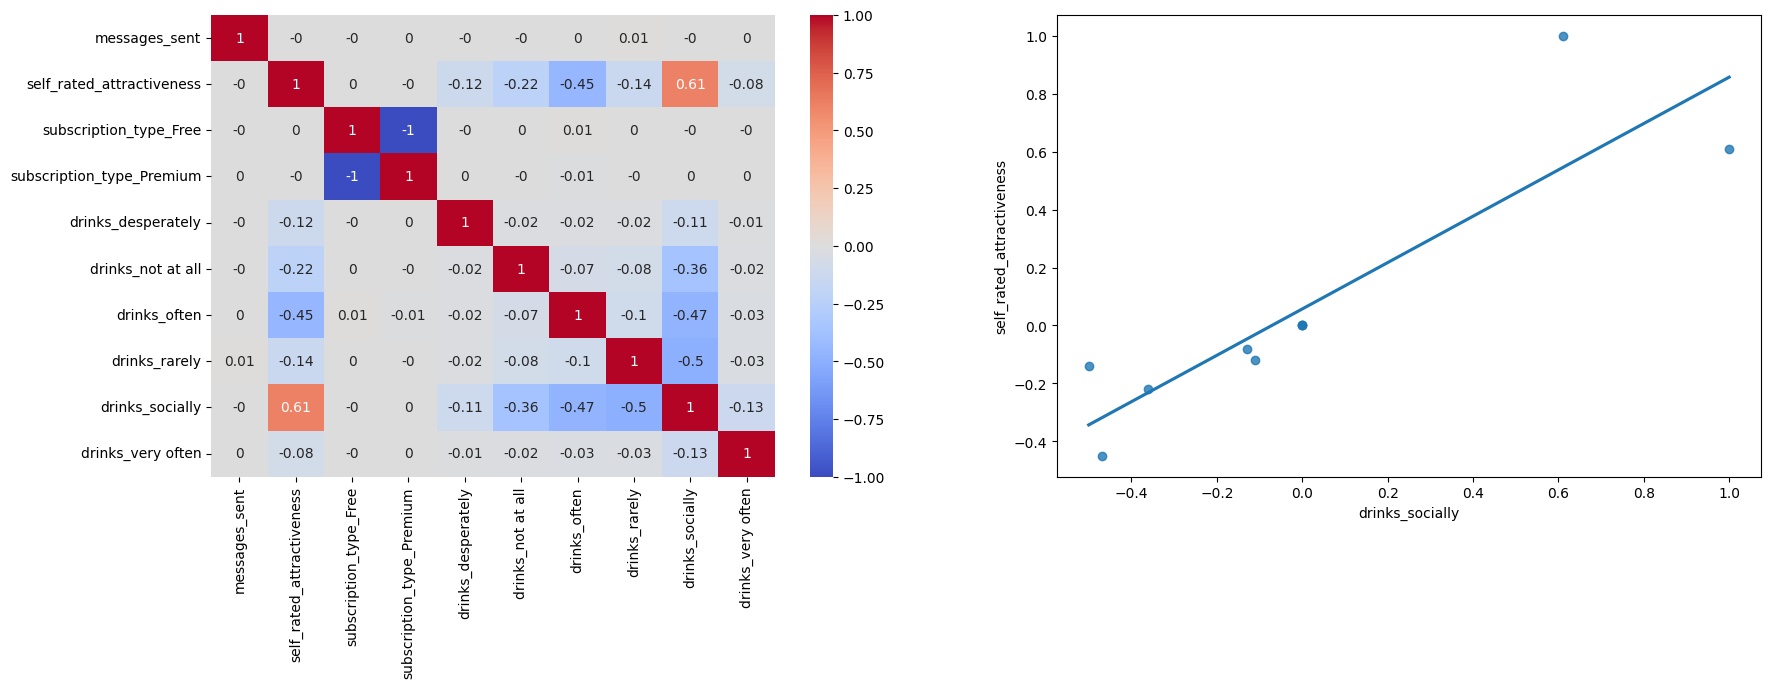

In [23]:
fig, ax = plt.subplots(1,2, figsize = (20, 6))


sns.heatmap(data=correlation_matrix, cmap='coolwarm', annot = True,  ax=ax[0])
#sns.scatterplot(data = df_dummies , y = 'self_rated_attractiveness', x ='drinks_socially',  ax=ax[1])
sns.regplot(y='self_rated_attractiveness', x='drinks_socially', data=correlation_matrix, ci=None,ax = ax[1])
plt.show()

-----

# Q8

<div dir='rtl'>
מצאו את ארבעת הקטגוריות הנפוצות ביותר בעמודה offspring 

<div dir='rtl'>
הציגו איור המשווה בין אחוז הגברים והנשים עבור כל אחת מהקטגוריות. 


In [24]:
top_offspring = df["offspring"].value_counts().index[:4]

In [25]:
df_top = df[df["offspring"].isin(top_offspring)]

# another option:
#df_top = df[
#    (df["offspring"] == top_offspring[0]) |
#    (df["offspring"] == top_offspring[1]) |
#    (df["offspring"] == top_offspring[2]) |
#    (df["offspring"] == top_offspring[3])
#]

In [26]:
df_percentage = df_top.groupby("gender")["offspring"].value_counts(normalize=True).mul(100).reset_index(name="percentage")
df_percentage 

,gender,offspring,percentage
0,f,doesn't have kids,40.860356
1,f,"doesn't have kids, but wants them",24.058577
2,f,"doesn't have kids, but might want them",19.691423
3,f,doesn't want kids,15.389644
4,m,doesn't have kids,43.146220
5,m,"doesn't have kids, but might want them",23.046989
6,m,doesn't want kids,17.025002
7,m,"doesn't have kids, but wants them",16.781788


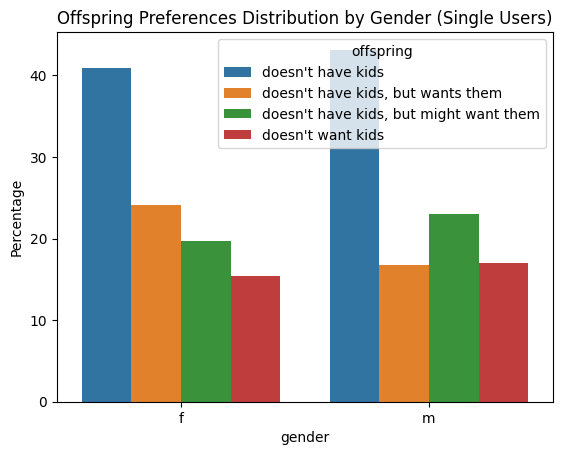

In [27]:
sns.barplot(data=df_percentage, x="gender", y="percentage", hue="offspring")
plt.ylabel("Percentage")
plt.title("Offspring Preferences Distribution by Gender (Single Users)")
plt.show()


### another option:

In [28]:
df8 = df.groupby('offspring')[['id']].count().sort_values(by='id', ascending = False).reset_index().head(4)
df8

,offspring,id
0,doesn't have kids,7560
1,"doesn't have kids, but might want them",3875
2,"doesn't have kids, but wants them",3565
3,doesn't want kids,2927


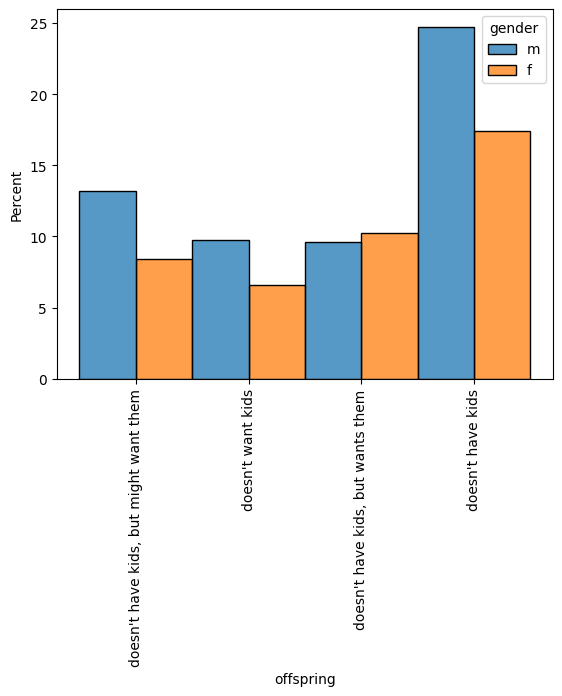

In [29]:
df8 = df[(df.offspring == "doesn't have kids") | (df.offspring == "doesn't have kids, but might want them")
         | (df.offspring == "doesn't have kids, but wants them") 
         | (df.offspring == "doesn't want kids")]

sns.histplot(data=df8 , x='offspring' ,stat='percent', hue='gender', multiple = 'dodge' )
plt.xticks(rotation=90)
plt.show()